# **Lab 7(A) - Laplacian Filter**

In [5]:
import cv2
import numpy as np

from IPython.display import Image, display
from matplotlib import pyplot as plt

plt.rc('text', usetex=False)




## Apply Laplacian Filter on Image to get Sharp Image

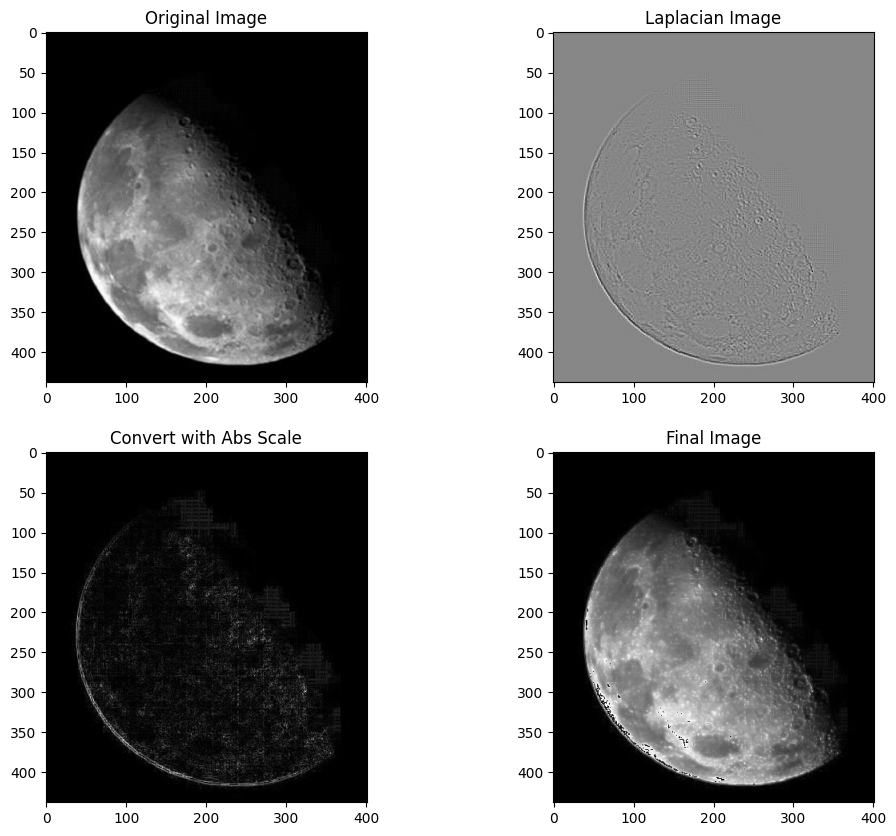

In [23]:

# ================ ( Laplacian Filter ) ===================


# 0. Image file path
imgFile = "moon.jpg"

# 1. Load image and convert to grayscale
img = cv2.imread(imgFile, 0)

# 2. Manually define the Laplacian Kernel
# This is the standard 3x3 kernel that detects horizontal and vertical edges
manual_kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
], dtype=np.float32)

# Alternative kernel: Detects diagonal edges as well
# manual_kernel = np.array([
#     [1,  1,  1],
#     [1, -8,  1],
#     [1,  1,  1]
# ], dtype=np.float32)

# 3. Apply the filter using filter2D
# -1 indicates the output image will have the same depth as the source
# However, for Laplacian, use cv2.CV_64F to avoid clipping negative values
laplacian_manual = cv2.filter2D(img, cv2.CV_64F, manual_kernel)

# 4. Take absolute value and convert back to 8-bit (0-255)
laplacian_abs = cv2.convertScaleAbs(laplacian_manual)

finalImage = img + laplacian_abs

# 5. Display images
plt.figure(figsize=(12, 10))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(222), plt.imshow(laplacian_manual, cmap='gray'), plt.title('Laplacian Image')
plt.subplot(223), plt.imshow(laplacian_abs, cmap='gray'), plt.title('Convert with Abs Scale')
plt.subplot(224), plt.imshow(finalImage, cmap='gray'), plt.title('Final Image')
plt.show()


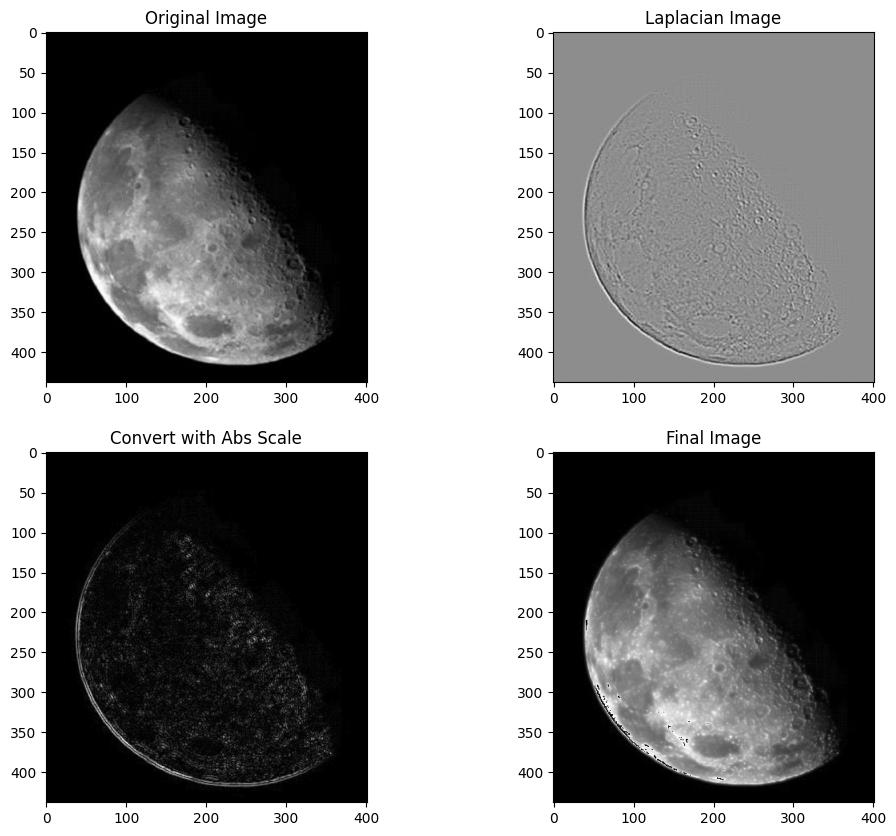

In [30]:
# ================== ( Laplacian Filter ) ===============

# 1. Optional: Apply Gaussian Blur to reduce noise
# This prevents the algorithm from picking up tiny details as edges
blurred = cv2.GaussianBlur(img, (3, 3), 0)

# 2. Apply the Laplacian Algorithm
# Use CV_64F to capture both positive and negative gradients (essential for edges)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

# 3. Convert back to 8-bit image to view it properly
laplacian_8bit = cv2.convertScaleAbs(laplacian)

# 4. Adding Laplace and origianl Image
finalImage2 = img + laplacian_8bit

# 5. Display images
plt.figure(figsize=(12, 10))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(222), plt.imshow(laplacian, cmap='gray'), plt.title('Laplacian Image')
plt.subplot(223), plt.imshow(laplacian_8bit, cmap='gray'), plt.title('Convert with Abs Scale')
plt.subplot(224), plt.imshow(finalImage2, cmap='gray'), plt.title('Final Image')
plt.show()




##